###Clics Banner Web , App

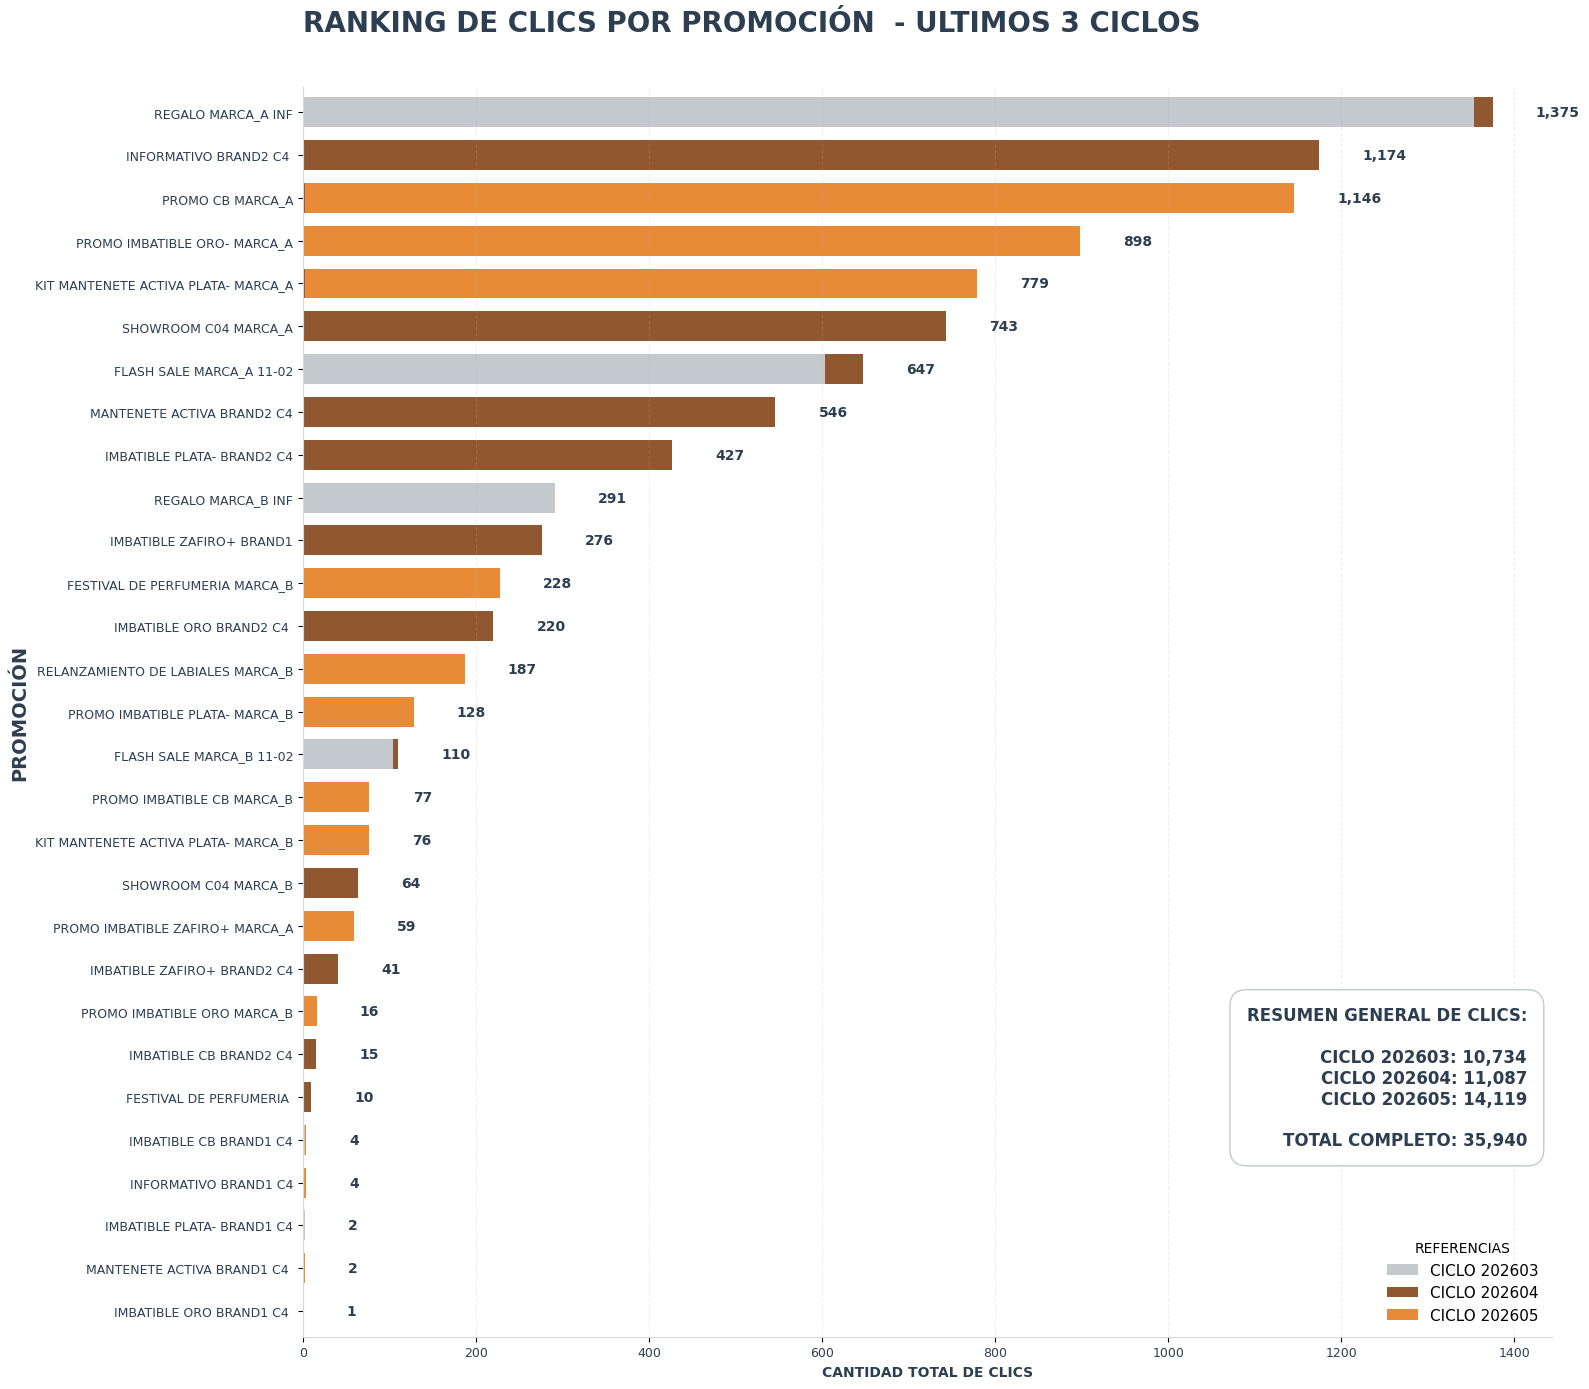

Gráfico generado con la paleta Marca_A.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 1. DEFINICIÓN DE PALETA COHERENTE MARCA_A
# ==========================================
MARCA_A_NARANJA = '#E67E22'
MARCA_A_MARRON  = '#83461A'
MARCA_A_GRIS    = '#BDC3C7'
MARCA_A_TEXTO   = '#2C3E50'
MARCA_A_BASE    = '#D5D8DC'

# Colores para los 3 ciclos (en orden: 03, 04, 05)
COLORES_CICLOS = [MARCA_A_GRIS, MARCA_A_MARRON, MARCA_A_NARANJA]

# ==========================================
# 2. FUNCIONES Y CARGA (Tu lógica original)
# ==========================================
def cargar_clics(archivo, columnas):
    df = pd.read_csv(archivo, skiprows=8, names=columnas, header=None)
    df = df.dropna(subset=['promotion_id'])
    df['clicks'] = pd.to_numeric(df['clicks'], errors='coerce').fillna(0).astype(int)
    df['cycle'] = pd.to_numeric(df['cycle'], errors='coerce').fillna(0).astype(int).astype(str)
    return df

cols_app = ['label', 'promotion_id', 'cycle', 'clicks']
cols_web = ['promotion_id', 'country', 'cycle', 'clicks']

df_app = cargar_clics('clics_bnr_app_clean.csv', cols_app)
df_web = cargar_clics('clics_bnr_web_clean.csv', cols_web)

df_total = pd.concat([
    df_app[['promotion_id', 'cycle', 'clicks']], 
    df_web[['promotion_id', 'cycle', 'clicks']]
])

ciclos_interes = ['202603', '202604', '202605']
df_filtered = df_total[df_total['cycle'].isin(ciclos_interes)]
totales_por_ciclo = df_filtered.groupby('cycle')['clicks'].sum()
gran_total = df_filtered['clicks'].sum()

df_url = pd.read_csv('Url_bnr_03_2026_clean.csv')
df_merged = pd.merge(
    df_filtered.groupby(['promotion_id', 'cycle'], as_index=False)['clicks'].sum(),
    df_url[['CODIGO GOOGLE ANALITYCS', 'NOMBRE EN GSP', 'MARCA']].drop_duplicates(subset=['CODIGO GOOGLE ANALITYCS']),
    left_on='promotion_id',
    right_on='CODIGO GOOGLE ANALITYCS',
    how='inner'
)

# Ranking Top 40
ranking_total = df_merged.groupby('NOMBRE EN GSP')['clicks'].sum().sort_values(ascending=False)
top_40_names = ranking_total.head(40).index

df_pivot = df_merged[df_merged['NOMBRE EN GSP'].isin(top_40_names)].pivot_table(
    index='NOMBRE EN GSP', columns='cycle', values='clicks', aggfunc='sum'
).fillna(0)

df_pivot = df_pivot.loc[top_40_names[::-1]]
df_pivot.index = [str(x).upper() for x in df_pivot.index]
df_pivot.columns = [f"CICLO {c}".upper() for c in df_pivot.columns]

# ==========================================
# 3. GENERAR GRÁFICO CON ESTILO COHERENTE
# ==========================================
fig, ax = plt.subplots(figsize=(16, 14), facecolor='white')

# Aplicamos los colores de la paleta en lugar de 'tab20'
df_pivot.plot(kind='barh', stacked=True, ax=ax, color=COLORES_CICLOS, alpha=0.9, width=0.7)

# Etiquetas de datos detalladas
for i, (name, row) in enumerate(df_pivot.iterrows()):
    cum_sum = 0
    for val in row:
        if val > 5000: # Solo mostramos si el valor es representativo
            ax.text(cum_sum + val/2, i, f'{int(val):,}', va='center', ha='center', 
                    fontsize=8, color='white', fontweight='bold')
        cum_sum += val
    # Total al final de la barra en color de texto corporativo
    ax.text(cum_sum + 50, i, f'{int(cum_sum):,}', va='center', ha='left', 
            fontsize=10, fontweight='bold', color=MARCA_A_TEXTO)

# Limpieza de Spines (Estilo similar a tu captura de pantalla)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(MARCA_A_BASE)
ax.spines['bottom'].set_color(MARCA_A_BASE)

# Formato de texto y títulos
plt.title('RANKING DE CLICS POR PROMOCIÓN  - ULTIMOS 3 CICLOS'.upper(), 
          fontsize=20, fontweight='bold', color=MARCA_A_TEXTO, pad=40, loc='left')

plt.xlabel('CANTIDAD TOTAL DE CLICS'.upper(), fontsize=10, fontweight='bold', color=MARCA_A_TEXTO)
plt.ylabel('PROMOCIÓN'.upper(), fontsize=14, fontweight='bold', color=MARCA_A_TEXTO)
ax.tick_params(axis='both', labelsize=9, labelcolor=MARCA_A_TEXTO)

# Cuadro de Resumen
texto_resumen = "RESUMEN GENERAL DE CLICS:\n\n"
for c in ciclos_interes:
    val_c = totales_por_ciclo.get(c, 0)
    texto_resumen += f"CICLO {c}: {val_c:,}\n"
texto_resumen += f"\nTOTAL COMPLETO: {gran_total:,}"

plt.text(0.98, 0.15, texto_resumen.upper(), transform=ax.transAxes, fontsize=12, fontweight='bold',
         bbox=dict(facecolor='white', alpha=0.9, edgecolor=MARCA_A_GRIS, boxstyle='round,pad=1'),
         ha='right', va='bottom', color=MARCA_A_TEXTO)

# Leyenda
ax.legend(title='REFERENCIAS'.upper(), loc='lower right', frameon=False, fontsize=11)

plt.grid(axis='x', linestyle='--', alpha=0.2)
plt.tight_layout()
plt.savefig('ranking_final_coherente.png')
plt.show()

print("Gráfico generado con la paleta Marca_A.")